# Аналитика логистических отправлений

Этот notebook показывает упрощённый полный аналитический цикл на синтетическом наборе из **10 000 строк и 10 столбцов**. Одна строка описывает одно логистическое отправление. Материал рассчитан на начинающих: новые термины поясняются обычным языком, а каждая строка кода снабжена русским комментарием.

Логика работы соответствует универсальному аналитическому пайплайну: бизнес-вопрос → проверка данных → очистка → расчёты → визуализация → статистическая проверка → выводы и рекомендации.

## 1. Цель анализа

Цель — определить, какие маршруты и виды транспорта связаны с повышенной стоимостью и задержками. Результат может использовать учебный руководитель логистики, чтобы понять, где требуется дополнительный контроль сроков и расходов.

Под **отправлением** понимается одна перевозка груза от города отправления до города назначения. Денежный показатель `delivery_cost_rub` отражает учебную стоимость доставки в рублях. Он не является прибылью компании: это сумма затрат или тарифа на конкретную перевозку.

## 2. Аналитические вопросы и гипотезы

Проверяются четыре понятных вопроса:

1. Как меняется число отправлений по месяцам?
2. Как различаются стоимость, срок и доля задержек у автомобильных, железнодорожных и авиационных перевозок?
3. Какие города и маршруты формируют основной объём отправлений?
4. Связаны ли вес груза и расстояние со стоимостью доставки?

Рабочие гипотезы:

- авиа обычно быстрее, но дороже автомобильной перевозки;
- тяжёлые грузы и длинные маршруты обычно стоят дороже;
- частота задержек может различаться между видами транспорта.

Гипотеза — это проверяемое предположение, а не заранее известный ответ.

## 3. Данные, единица наблюдения и ожидаемый результат

Источник — синтетический CSV-файл `logistics_shipments_10000.csv`. Данные охватывают 2025 год и созданы только для обучения.

**Единица наблюдения, или grain:** одно отправление. Поэтому `shipment_id` должен быть уникальным после удаления полных дубликатов.

Ожидаемые результаты:

- очищенный CSV с теми же десятью исходными полями;
- таблицы ключевых показателей;
- временной, транспортный и маршрутный анализ;
- географическая визуализация маршрутов;
- корреляционная матрица;
- статистическая проверка гипотезы;
- итоговый дашборд и рекомендации.

## 4. Подготовка окружения

Импорт подключает готовые библиотеки. `pandas` работает с таблицами, `NumPy` выполняет числовые расчёты, `matplotlib` и `seaborn` строят графики, а `SciPy` содержит статистические тесты.

In [1]:
# Импортируем Path для безопасной работы с путями к файлам.
from pathlib import Path
# Импортируем warnings для управления некритичными предупреждениями библиотек.
import warnings
# Импортируем math для расчёта расстояний между городами.
import math
# Импортируем NumPy для числовых расчётов.
import numpy as np
# Импортируем pandas для работы с таблицами.
import pandas as pd
# Импортируем matplotlib для построения графиков.
import matplotlib.pyplot as plt
# Импортируем seaborn для статистических графиков и тепловых карт.
import seaborn as sns
# Импортируем непараметрический тест Манна—Уитни.
from scipy.stats import mannwhitneyu
# Импортируем display и Markdown для удобного вывода в notebook.
from IPython.display import display, Markdown

# Скрываем только некритичные FutureWarning, чтобы учебный вывод оставался читаемым.
warnings.filterwarnings('ignore', category=FutureWarning)
# Фиксируем случайное зерно для воспроизводимых расчётов.
RANDOM_SEED = 20260728
# Создаём генератор случайных чисел с фиксированным зерном.
rng = np.random.default_rng(RANDOM_SEED)
# Устанавливаем единый спокойный стиль графиков.
sns.set_theme(style='whitegrid', context='notebook')
# Устанавливаем шрифт с поддержкой кириллицы.
plt.rcParams['font.family'] = 'DejaVu Sans'
# Устанавливаем размер графика по умолчанию.
plt.rcParams['figure.figsize'] = (11, 6)
# Показываем до 30 столбцов в таблицах pandas.
pd.set_option('display.max_columns', 30)
# Показываем числа с двумя знаками после запятой.
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

# Определяем рабочую папку как папку, где запускается notebook.
DATA_DIR = Path('.')
# Формируем путь к исходному CSV-файлу.
RAW_DATA_PATH = DATA_DIR / 'logistics_shipments_10000.csv'
# Формируем путь для сохранения очищенного CSV-файла.
CLEAN_DATA_PATH = DATA_DIR / 'logistics_shipments_clean.csv'
# Формируем путь для сохранения итогового дашборда.
DASHBOARD_PATH = DATA_DIR / 'logistics_dashboard.png'

## 5. Загрузка данных

Метод `pd.read_csv()` читает CSV-файл и создаёт объект `DataFrame`. DataFrame можно представить как программную таблицу со строками и столбцами. После загрузки проверяются размер, начало и конец файла.

In [2]:
# Проверяем, что исходный файл находится рядом с notebook.
assert RAW_DATA_PATH.exists(), f'Файл не найден: {RAW_DATA_PATH.resolve()}'
# Загружаем исходный CSV в таблицу raw_df.
raw_df = pd.read_csv(RAW_DATA_PATH, encoding='utf-8-sig')
# Печатаем количество строк и столбцов.
print(f'Размер исходного датасета: {raw_df.shape[0]:,} строк и {raw_df.shape[1]} столбцов.')
# Показываем первые пять строк.
display(raw_df.head())
# Показываем последние пять строк.
display(raw_df.tail())

Размер исходного датасета: 10,000 строк и 10 столбцов.


,shipment_id,order_date,origin_city,destination_city,transport_type,cargo_weight_kg,planned_days,actual_days,delivery_cost_rub,delivery_status
0,SHP009777,2025-11-28,Казань,Нижний Новгород,Авто,43.70,2,1,"1,764.86",В срок
1,SHP003015,2025-06-21,Новосибирск,Ростов-на-Дону,Железная дорога,112.10,7,7,"5,260.10",В срок
2,SHP005549,2025-08-14,Москва,Ростов-на-Дону,Авто,756.20,3,3,"5,187.19",В срок
3,SHP005247,2025-04-27,Санкт-Петербург,Уфа,Авто,36.10,5,5,"3,615.44",В срок
4,SHP000858,2025-09-25,Москва,Пермь,Железная дорога,191.90,4,4,"3,375.88",В срок


,shipment_id,order_date,origin_city,destination_city,transport_type,cargo_weight_kg,planned_days,actual_days,delivery_cost_rub,delivery_status
9995,SHP007253,2025-10-31,Казань,Пермь,Железная дорога,154.80,3,3,"2,508.56",В срок
9996,SHP000673,2025-03-21,Новосибирск,Москва,Авто,164.50,7,8,"6,289.06",Задержка
9997,SHP009287,2025-12-14,Новосибирск,Уфа,Железная дорога,164.70,5,5,"4,379.21",В срок
9998,SHP008856,2025-05-25,Москва,Самара,Авто,338.60,3,3,"3,012.46",В срок
9999,SHP001819,2025-05-22,Москва,Ростов-на-Дону,Железная дорога,151.30,4,4,"2,727.65",В срок


## 6. Словарь десяти полей

| Поле | Смысл |
|---|---|
| `shipment_id` | уникальный идентификатор отправления |
| `order_date` | дата оформления отправления |
| `origin_city` | город отправления |
| `destination_city` | город назначения |
| `transport_type` | вид транспорта |
| `cargo_weight_kg` | вес груза в килограммах |
| `planned_days` | плановый срок в днях |
| `actual_days` | фактический срок в днях |
| `delivery_cost_rub` | стоимость доставки в рублях |
| `delivery_status` | результат по сроку: в срок или задержка |

Плановый срок — это обещанный период доставки. Фактический срок показывает, сколько дней заняла перевозка в данных. Задержка возникает, когда фактический срок больше планового.

## 7. Первичный осмотр структуры

Метод `info()` показывает типы столбцов и число заполненных значений. Метод `describe()` рассчитывает базовую статистику: минимум, максимум, среднее, медиану через квартиль 50% и разброс.

In [3]:
# Выводим техническую информацию о таблице.
raw_df.info()
# Показываем описательную статистику числовых столбцов.
display(raw_df.describe(include='number').T)
# Показываем число уникальных значений в каждом столбце.
display(raw_df.nunique(dropna=False).to_frame('unique_values'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipment_id        10000 non-null  object 
 1   order_date         10000 non-null  object 
 2   origin_city        10000 non-null  object 
 3   destination_city   10000 non-null  object 
 4   transport_type     9940 non-null   object 
 5   cargo_weight_kg    9956 non-null   float64
 6   planned_days       10000 non-null  int64  
 7   actual_days        10000 non-null  int64  
 8   delivery_cost_rub  9960 non-null   float64
 9   delivery_status    10000 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 781.4+ KB


,count,mean,std,min,25%,50%,75%,max
cargo_weight_kg,"9,956.00",385.82,"1,596.30",-5.00,156.90,259.70,422.10,"50,000.00"
planned_days,"10,000.00",3.56,1.70,0.00,3.00,3.00,4.00,45.00
actual_days,"10,000.00",3.96,2.35,0.00,3.00,4.00,5.00,60.00
delivery_cost_rub,"9,960.00","6,308.81","30,157.72",-100.00,"2,990.67","3,862.51","5,755.07","999,999.00"


,unique_values
shipment_id,9975
order_date,464
origin_city,10
destination_city,19
transport_type,7
cargo_weight_kg,5175
planned_days,8
actual_days,13
delivery_cost_rub,9829
delivery_status,4


## 8. Проверка типов и преобразование даты

Дата часто загружается как обычный текст. Метод `pd.to_datetime()` превращает текст в календарный тип. Параметр `errors='coerce'` заменяет нераспознанные даты на пропуск, чтобы ошибка не оставалась скрытой.

In [4]:
# Создаём рабочую копию, чтобы исходная таблица оставалась неизменной.
df = raw_df.copy()
# Убираем случайные пробелы из названий столбцов и приводим их к нижнему регистру.
df.columns = df.columns.str.strip().str.lower()
# Преобразуем смешанные форматы дат в единый тип datetime.
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True, errors='coerce')
# Считаем количество дат, которые не удалось распознать.
invalid_dates = int(df['order_date'].isna().sum())
# Печатаем результат проверки дат.
print(f'Нераспознанных дат после преобразования: {invalid_dates}')
# Показываем обновлённые типы столбцов.
df.info()

Нераспознанных дат после преобразования: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   shipment_id        10000 non-null  object        
 1   order_date         10000 non-null  datetime64[ns]
 2   origin_city        10000 non-null  object        
 3   destination_city   10000 non-null  object        
 4   transport_type     9940 non-null   object        
 5   cargo_weight_kg    9956 non-null   float64       
 6   planned_days       10000 non-null  int64         
 7   actual_days        10000 non-null  int64         
 8   delivery_cost_rub  9960 non-null   float64       
 9   delivery_status    10000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 781.4+ KB


## 9. Пропущенные значения

Пропуск означает, что значение отсутствует. Он не всегда равен нулю. Например, отсутствие стоимости не означает бесплатную доставку. Сначала измеряется масштаб проблемы, а затем выбирается способ обработки.

In [5]:
# Считаем количество пропусков в каждом столбце.
missing_count = df.isna().sum()
# Считаем долю пропусков в процентах.
missing_share = df.isna().mean().mul(100)
# Объединяем количество и долю пропусков в одну таблицу.
missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_share_pct': missing_share})
# Оставляем только столбцы, где обнаружены пропуски.
missing_report = missing_report.loc[missing_report['missing_count'] > 0]
# Сортируем отчёт от большей доли пропусков к меньшей.
missing_report = missing_report.sort_values('missing_share_pct', ascending=False)
# Показываем отчёт по пропускам.
display(missing_report)

,missing_count,missing_share_pct
transport_type,60,0.60
cargo_weight_kg,44,0.44
delivery_cost_rub,40,0.40


## 10. Дубликаты и уникальность идентификатора

Полный дубликат — строка, которая целиком повторяет другую строку. Если такой дубль оставить, количество отправлений и общая стоимость будут завышены. После удаления дублей `shipment_id` должен стать уникальным.

In [6]:
# Считаем полные дубликаты строк.
full_duplicate_count = int(df.duplicated().sum())
# Считаем повторяющиеся идентификаторы отправлений.
duplicate_id_count = int(df['shipment_id'].duplicated(keep=False).sum())
# Печатаем число полных дубликатов.
print(f'Полных дубликатов: {full_duplicate_count}')
# Печатаем число строк с повторяющимся shipment_id.
print(f'Строк с повторяющимся shipment_id: {duplicate_id_count}')
# Удаляем полные дубликаты и создаём независимую копию.
df = df.drop_duplicates().copy()
# Проверяем число строк после удаления полных дубликатов.
print(f'Строк после удаления полных дубликатов: {len(df):,}')

Полных дубликатов: 25
Строк с повторяющимся shipment_id: 50
Строк после удаления полных дубликатов: 9,975


## 11. Согласованность категорий

Категории должны записываться одинаково. Значения `Авиа`, `АВИА` и `авиа ` описывают один вид транспорта, но программа воспринимает их как разные группы. Стандартизация объединяет такие варианты.

In [7]:
# Создаём справочник корректных названий городов по нижнему регистру.
city_map = {
    'москва': 'Москва',
    'санкт-петербург': 'Санкт-Петербург',
    'казань': 'Казань',
    'нижний новгород': 'Нижний Новгород',
    'екатеринбург': 'Екатеринбург',
    'самара': 'Самара',
    'ростов-на-дону': 'Ростов-на-Дону',
    'новосибирск': 'Новосибирск',
    'пермь': 'Пермь',
    'уфа': 'Уфа'
}
# Очищаем и стандартизируем города отправления.
df['origin_city'] = df['origin_city'].astype('string').str.strip().str.lower().map(city_map)
# Очищаем и стандартизируем города назначения.
df['destination_city'] = df['destination_city'].astype('string').str.strip().str.lower().map(city_map)
# Создаём справочник вариантов вида транспорта.
transport_map = {'авто': 'Авто', 'ж/д': 'Железная дорога', 'железная дорога': 'Железная дорога', 'авиа': 'Авиа'}
# Очищаем и стандартизируем вид транспорта.
df['transport_type'] = df['transport_type'].astype('string').str.strip().str.lower().map(transport_map)
# Создаём справочник вариантов статуса.
status_map = {'в срок': 'В срок', 'задержка': 'Задержка', 'задержано': 'Задержка'}
# Очищаем и стандартизируем статус доставки.
df['delivery_status'] = df['delivery_status'].astype('string').str.strip().str.lower().map(status_map)
# Показываем итоговые справочники категорий.
print('Виды транспорта:', sorted(df['transport_type'].dropna().unique()))
# Показываем итоговые статусы.
print('Статусы:', sorted(df['delivery_status'].dropna().unique()))

Виды транспорта: ['Авиа', 'Авто', 'Железная дорога']
Статусы: ['В срок', 'Задержка']


## 12. Числовые правила и аномалии

Для учебной задачи принимаются простые бизнес-правила:

- вес должен быть больше нуля и не превышать 2 000 кг;
- плановый и фактический сроки должны находиться от 1 до 30 дней;
- стоимость должна быть положительной и ниже 200 000 рублей.

Значение за пределами правила не всегда является ошибкой в реальной компании. Здесь границы заданы как учебное условие и должны быть подтверждены владельцем данных в рабочем проекте.

In [8]:
# Создаём маску некорректного веса.
invalid_weight_mask = ~df['cargo_weight_kg'].between(1, 2000) | df['cargo_weight_kg'].isna()
# Создаём маску некорректного планового срока.
invalid_planned_mask = ~df['planned_days'].between(1, 30) | df['planned_days'].isna()
# Создаём маску некорректного фактического срока.
invalid_actual_mask = ~df['actual_days'].between(1, 30) | df['actual_days'].isna()
# Создаём маску некорректной стоимости.
invalid_cost_mask = ~df['delivery_cost_rub'].between(1, 200000) | df['delivery_cost_rub'].isna()
# Собираем результаты проверки в таблицу.
rule_report = pd.DataFrame({
    'rule': ['Вес 1–2000 кг', 'Плановый срок 1–30 дней', 'Фактический срок 1–30 дней', 'Стоимость 1–200000 руб.'],
    'invalid_rows': [invalid_weight_mask.sum(), invalid_planned_mask.sum(), invalid_actual_mask.sum(), invalid_cost_mask.sum()]
})
# Показываем отчёт по нарушениям правил.
display(rule_report)

,rule,invalid_rows
0,Вес 1–2000 кг,64
1,Плановый срок 1–30 дней,16
2,Фактический срок 1–30 дней,16
3,Стоимость 1–200000 руб.,58


## 13. Очистка и приведение к консистентной форме

Консистентность означает внутреннюю согласованность таблицы. Пропущенный вид транспорта заполняется наиболее частым видом на том же маршруте. Некорректные числовые значения заменяются медианой внутри подходящей группы. Медиана — центральное значение упорядоченного ряда; она меньше среднего чувствительна к очень большим выбросам.

In [9]:
# Создаём название маршрута для временной группировки при заполнении пропусков.
route_for_fill = df['origin_city'].astype('string') + ' → ' + df['destination_city'].astype('string')
# Рассчитываем наиболее частый вид транспорта внутри каждого маршрута.
route_transport_mode = df.groupby(route_for_fill)['transport_type'].transform(lambda series: series.mode().iloc[0] if not series.mode().empty else pd.NA)
# Заполняем отсутствующий вид транспорта модой маршрута.
df['transport_type'] = df['transport_type'].fillna(route_transport_mode)
# Заполняем редкие оставшиеся пропуски общей модой.
df['transport_type'] = df['transport_type'].fillna(df['transport_type'].mode().iloc[0])
# Временно заменяем некорректный вес на пропуск.
df.loc[invalid_weight_mask, 'cargo_weight_kg'] = np.nan
# Рассчитываем медианный вес внутри каждого вида транспорта.
weight_median_by_transport = df.groupby('transport_type')['cargo_weight_kg'].transform('median')
# Заполняем пропущенный вес медианой вида транспорта.
df['cargo_weight_kg'] = df['cargo_weight_kg'].fillna(weight_median_by_transport)
# Временно заменяем некорректный плановый срок на пропуск.
df.loc[invalid_planned_mask, 'planned_days'] = np.nan
# Временно заменяем некорректный фактический срок на пропуск.
df.loc[invalid_actual_mask, 'actual_days'] = np.nan
# Создаём маршрут после стандартизации городов.
df['route_temp'] = df['origin_city'] + ' → ' + df['destination_city']
# Рассчитываем медианный плановый срок по маршруту и виду транспорта.
planned_median = df.groupby(['route_temp', 'transport_type'])['planned_days'].transform('median')
# Заполняем плановый срок медианой подходящей группы.
df['planned_days'] = df['planned_days'].fillna(planned_median)
# Рассчитываем медианный фактический срок по маршруту и виду транспорта.
actual_median = df.groupby(['route_temp', 'transport_type'])['actual_days'].transform('median')
# Заполняем фактический срок медианой подходящей группы.
df['actual_days'] = df['actual_days'].fillna(actual_median)
# Приводим сроки к целым числам.
df[['planned_days', 'actual_days']] = df[['planned_days', 'actual_days']].round().astype('int64')
# Временно заменяем некорректную стоимость на пропуск.
df.loc[invalid_cost_mask, 'delivery_cost_rub'] = np.nan
# Рассчитываем медианную стоимость по маршруту и виду транспорта.
cost_median = df.groupby(['route_temp', 'transport_type'])['delivery_cost_rub'].transform('median')
# Заполняем стоимость медианой подходящей группы.
df['delivery_cost_rub'] = df['delivery_cost_rub'].fillna(cost_median)
# Пересчитываем статус по фактическому и плановому сроку.
df['delivery_status'] = np.where(df['actual_days'] > df['planned_days'], 'Задержка', 'В срок')
# Удаляем временный технический столбец.
df = df.drop(columns='route_temp')

## 14. Контроль качества после очистки

Очистка считается завершённой только после повторной проверки. `assert` останавливает выполнение, если условие нарушено. Это защищает последующие расчёты от скрытых проблем.

In [10]:
# Определяем критические поля, необходимые для анализа.
critical_columns = ['shipment_id', 'order_date', 'origin_city', 'destination_city', 'transport_type', 'cargo_weight_kg', 'planned_days', 'actual_days', 'delivery_cost_rub', 'delivery_status']
# Проверяем отсутствие пропусков в критических полях.
assert df[critical_columns].isna().sum().sum() == 0, 'После очистки остались критические пропуски.'
# Проверяем уникальность идентификатора отправления.
assert df['shipment_id'].is_unique, 'shipment_id должен быть уникальным.'
# Проверяем допустимый диапазон веса.
assert df['cargo_weight_kg'].between(1, 2000).all(), 'Вес вышел за допустимый диапазон.'
# Проверяем допустимый диапазон планового срока.
assert df['planned_days'].between(1, 30).all(), 'Плановый срок вышел за допустимый диапазон.'
# Проверяем допустимый диапазон фактического срока.
assert df['actual_days'].between(1, 30).all(), 'Фактический срок вышел за допустимый диапазон.'
# Проверяем допустимый диапазон стоимости.
assert df['delivery_cost_rub'].between(1, 200000).all(), 'Стоимость вышла за допустимый диапазон.'
# Проверяем согласованность статуса со сроками.
assert ((df['delivery_status'] == 'Задержка') == (df['actual_days'] > df['planned_days'])).all(), 'Статус не согласован со сроками.'
# Печатаем итоговый размер очищенной таблицы.
print(f'Очищенная таблица: {df.shape[0]:,} строк и {df.shape[1]} столбцов.')

Очищенная таблица: 9,975 строк и 10 столбцов.


## 15. Производные признаки и расстояние между городами

Производный признак рассчитывается из исходных полей и помогает отвечать на аналитический вопрос. В рабочей копии создаются месяц, маршрут, число дней задержки и бинарный признак своевременной доставки.

Расстояние не хранится в исходном CSV, чтобы сохранить ограничение в десять столбцов. Оно рассчитывается по справочнику координат городов формулой гаверсинуса. Эта формула оценивает кратчайшее расстояние по поверхности Земли между двумя точками. Реальный автомобильный или железнодорожный путь обычно длиннее, поэтому рассчитанное расстояние используется только как приближённый числовой признак, а не как географическая визуализация.


In [11]:
# Создаём отдельную таблицу для анализа с производными признаками.
analysis_df = df.copy()
# Создаём календарный месяц отправления.
analysis_df['month'] = analysis_df['order_date'].dt.to_period('M').dt.to_timestamp()
# Создаём понятное текстовое название маршрута.
analysis_df['route'] = analysis_df['origin_city'] + ' → ' + analysis_df['destination_city']
# Рассчитываем число дней задержки, не допуская отрицательных значений.
analysis_df['delay_days'] = (analysis_df['actual_days'] - analysis_df['planned_days']).clip(lower=0)
# Создаём признак своевременной доставки: 1 означает «в срок», 0 означает «задержка».
analysis_df['on_time_flag'] = (analysis_df['delivery_status'] == 'В срок').astype('int64')

# Создаём справочник широты и долготы учебных городов.
CITY_COORDS = {
    'Москва': (55.7558, 37.6176),
    'Санкт-Петербург': (59.9343, 30.3351),
    'Казань': (55.7961, 49.1064),
    'Нижний Новгород': (56.2965, 43.9361),
    'Екатеринбург': (56.8389, 60.6057),
    'Самара': (53.1959, 50.1008),
    'Ростов-на-Дону': (47.2357, 39.7015),
    'Новосибирск': (55.0084, 82.9357),
    'Пермь': (58.0105, 56.2502),
    'Уфа': (54.7388, 55.9721)
}

# Определяем функцию расчёта расстояния по формуле гаверсинуса.
def haversine_distance(origin_city, destination_city):
    # Получаем координаты города отправления.
    lat1, lon1 = CITY_COORDS[origin_city]
    # Получаем координаты города назначения.
    lat2, lon2 = CITY_COORDS[destination_city]
    # Задаём средний радиус Земли в километрах.
    earth_radius_km = 6371.0
    # Переводим первую широту из градусов в радианы.
    phi1 = math.radians(lat1)
    # Переводим вторую широту из градусов в радианы.
    phi2 = math.radians(lat2)
    # Рассчитываем разность широт в радианах.
    delta_phi = math.radians(lat2 - lat1)
    # Рассчитываем разность долгот в радианах.
    delta_lambda = math.radians(lon2 - lon1)
    # Рассчитываем промежуточную часть формулы гаверсинуса.
    haversine_value = math.sin(delta_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    # Возвращаем расстояние по дуге земной поверхности.
    return earth_radius_km * 2 * math.atan2(math.sqrt(haversine_value), math.sqrt(1 - haversine_value))

# Рассчитываем расстояние для каждой строки таблицы.
analysis_df['distance_km'] = analysis_df.apply(lambda row: haversine_distance(row['origin_city'], row['destination_city']), axis=1)
# Округляем расстояние до целого километра для удобства чтения.
analysis_df['distance_km'] = analysis_df['distance_km'].round().astype('int64')
# Показываем первые строки с производными признаками.
display(analysis_df.head())

,shipment_id,order_date,origin_city,destination_city,transport_type,cargo_weight_kg,planned_days,actual_days,delivery_cost_rub,delivery_status,month,route,delay_days,on_time_flag,distance_km
0,SHP009777,2025-11-28,Казань,Нижний Новгород,Авто,43.70,2,1,"1,764.86",В срок,2025-11-01,Казань → Нижний Новгород,0,1,326
1,SHP003015,2025-06-21,Новосибирск,Ростов-на-Дону,Железная дорога,112.10,7,7,"5,260.10",В срок,2025-06-01,Новосибирск → Ростов-на-Дону,0,1,3084
2,SHP005549,2025-08-14,Москва,Ростов-на-Дону,Авто,756.20,3,3,"5,187.19",В срок,2025-08-01,Москва → Ростов-на-Дону,0,1,958
3,SHP005247,2025-04-27,Санкт-Петербург,Уфа,Авто,36.10,5,5,"3,615.44",В срок,2025-04-01,Санкт-Петербург → Уфа,0,1,1631
4,SHP000858,2025-09-25,Москва,Пермь,Железная дорога,191.90,4,4,"3,375.88",В срок,2025-09-01,Москва → Пермь,0,1,1155


## 16. Общие показатели логистики

Ключевые показатели отвечают на базовые управленческие вопросы:

- количество отправлений показывает объём работы;
- общая стоимость показывает масштаб расходов или тарификации;
- средняя стоимость характеризует типичный денежный уровень, но чувствительна к дорогим перевозкам;
- медианная стоимость показывает центральное отправление и устойчивее к выбросам;
- доля доставок в срок показывает, какая часть перевозок уложилась в обещанный срок.

In [12]:
# Считаем общее количество очищенных отправлений.
total_shipments = int(analysis_df['shipment_id'].nunique())
# Считаем общую стоимость доставки.
total_cost = float(analysis_df['delivery_cost_rub'].sum())
# Считаем среднюю стоимость одного отправления.
average_cost = float(analysis_df['delivery_cost_rub'].mean())
# Считаем медианную стоимость одного отправления.
median_cost = float(analysis_df['delivery_cost_rub'].median())
# Считаем долю отправлений, доставленных в срок.
on_time_share = float(analysis_df['on_time_flag'].mean())
# Собираем показатели в компактную таблицу.
kpi_table = pd.DataFrame({
    'Показатель': ['Отправления', 'Общая стоимость, руб.', 'Средняя стоимость, руб.', 'Медианная стоимость, руб.', 'Доля в срок'],
    'Значение': [total_shipments, total_cost, average_cost, median_cost, on_time_share]
})
# Показываем таблицу ключевых показателей.
display(kpi_table)

,Показатель,Значение
0,Отправления,"9,975.00"
1,"Общая стоимость, руб.","54,010,493.88"
2,"Средняя стоимость, руб.","5,414.59"
3,"Медианная стоимость, руб.","3,859.57"
4,Доля в срок,0.81


## 17. Распределения и выбросы

Гистограмма показывает, как часто встречаются разные значения. Boxplot, или «ящик с усами», кратко показывает медиану, центральные 50% наблюдений и потенциальные выбросы.

Метод IQR использует межквартильный размах: разницу между 75-м и 25-м процентилями. Значения далеко за пределами этого диапазона отмечаются как потенциальные выбросы. Они не удаляются автоматически, потому что дорогая доставка может быть реальной.

Потенциально дорогих отправлений по правилу IQR: 1,319


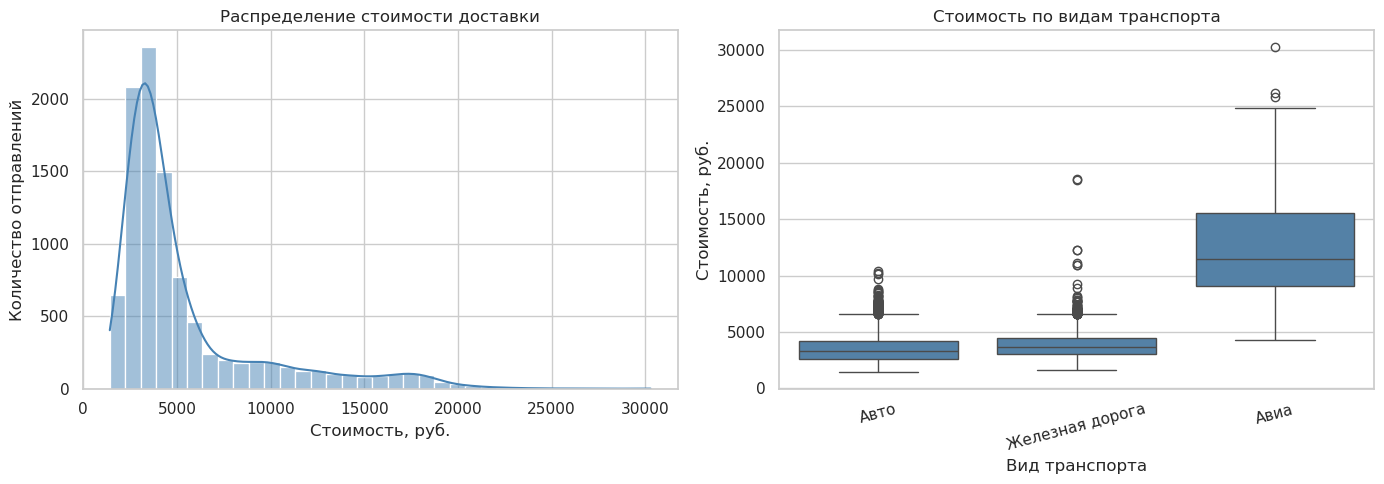

In [13]:
# Рассчитываем первый квартиль стоимости.
q1_cost = analysis_df['delivery_cost_rub'].quantile(0.25)
# Рассчитываем третий квартиль стоимости.
q3_cost = analysis_df['delivery_cost_rub'].quantile(0.75)
# Рассчитываем межквартильный размах.
iqr_cost = q3_cost - q1_cost
# Рассчитываем верхнюю границу потенциальных выбросов.
upper_cost_limit = q3_cost + 1.5 * iqr_cost
# Создаём признак потенциально высокой стоимости.
analysis_df['high_cost_outlier'] = analysis_df['delivery_cost_rub'] > upper_cost_limit
# Печатаем число потенциальных выбросов.
print(f'Потенциально дорогих отправлений по правилу IQR: {analysis_df["high_cost_outlier"].sum():,}')

# Создаём фигуру из двух областей.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Строим гистограмму стоимости.
sns.histplot(data=analysis_df, x='delivery_cost_rub', bins=35, kde=True, color='steelblue', ax=axes[0])
# Добавляем заголовок гистограммы.
axes[0].set_title('Распределение стоимости доставки')
# Подписываем горизонтальную ось.
axes[0].set_xlabel('Стоимость, руб.')
# Подписываем вертикальную ось.
axes[0].set_ylabel('Количество отправлений')
# Строим boxplot стоимости по видам транспорта.
sns.boxplot(data=analysis_df, x='transport_type', y='delivery_cost_rub', color='steelblue', ax=axes[1])
# Добавляем заголовок boxplot.
axes[1].set_title('Стоимость по видам транспорта')
# Подписываем горизонтальную ось.
axes[1].set_xlabel('Вид транспорта')
# Подписываем вертикальную ось.
axes[1].set_ylabel('Стоимость, руб.')
# Поворачиваем подписи категорий для читаемости.
axes[1].tick_params(axis='x', rotation=15)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем графики.
plt.show()

## 18. Временная динамика

Месячная агрегация помогает увидеть изменение объёма и доли задержек во времени. Метод `groupby()` объединяет строки в группы, а `agg()` рассчитывает несколько показателей для каждой группы.

,month,shipments,total_cost_rub,on_time_share
0,2025-01-01,857,"4,540,688.96",0.74
1,2025-02-01,752,"3,953,888.15",0.75
2,2025-03-01,901,"4,888,734.85",0.81
3,2025-04-01,865,"4,653,058.85",0.83
4,2025-05-01,809,"4,499,264.92",0.82
5,2025-06-01,827,"4,671,405.29",0.84
6,2025-07-01,859,"4,521,245.76",0.85
7,2025-08-01,799,"4,236,269.06",0.85
8,2025-09-01,851,"4,742,837.08",0.81
9,2025-10-01,823,"4,462,688.98",0.80


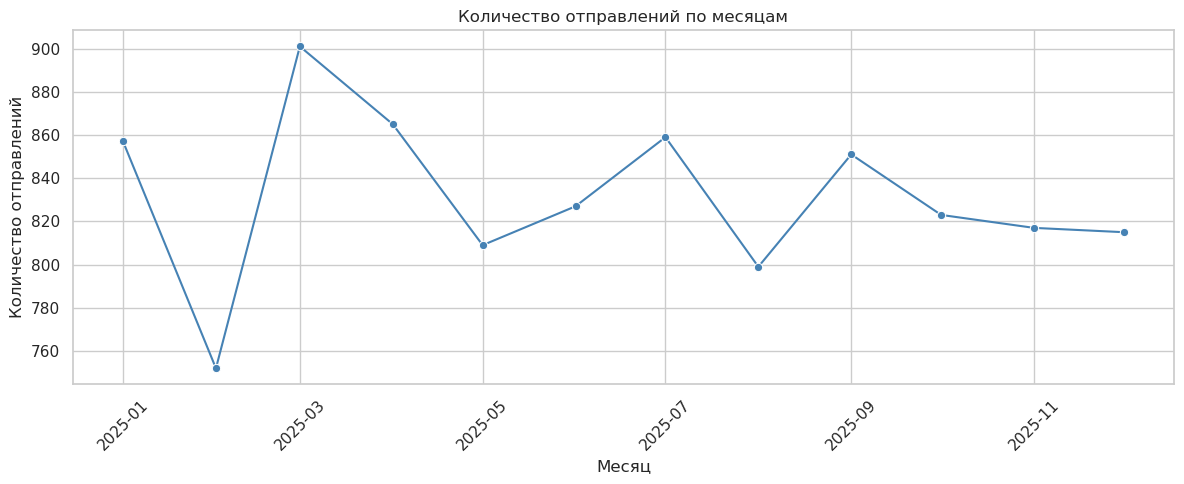

In [14]:
# Группируем отправления по календарному месяцу.
monthly_summary = analysis_df.groupby('month', as_index=False).agg(
    shipments=('shipment_id', 'nunique'),
    total_cost_rub=('delivery_cost_rub', 'sum'),
    on_time_share=('on_time_flag', 'mean')
)
# Показываем месячную сводку.
display(monthly_summary)
# Создаём фигуру для месячной динамики.
fig, ax = plt.subplots(figsize=(12, 5))
# Строим линию количества отправлений.
sns.lineplot(data=monthly_summary, x='month', y='shipments', marker='o', color='steelblue', ax=ax)
# Добавляем заголовок.
ax.set_title('Количество отправлений по месяцам')
# Подписываем горизонтальную ось.
ax.set_xlabel('Месяц')
# Подписываем вертикальную ось.
ax.set_ylabel('Количество отправлений')
# Поворачиваем подписи месяцев.
ax.tick_params(axis='x', rotation=45)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем график.
plt.show()

## 19. Сравнение видов транспорта

Средняя стоимость показывает денежный уровень, средний фактический срок — скорость, а доля в срок — надёжность выполнения обещания. Ни один показатель не следует оценивать отдельно: быстрый транспорт может быть дорогим, а дешёвый — медленным.

,transport_type,shipments,average_cost_rub,median_cost_rub,average_actual_days,on_time_share
1,Авто,4079,"3,525.59","3,308.44",3.81,0.76
2,Железная дорога,3887,"3,859.96","3,626.97",4.75,0.80
0,Авиа,2009,"12,257.81","11,487.02",2.50,0.89


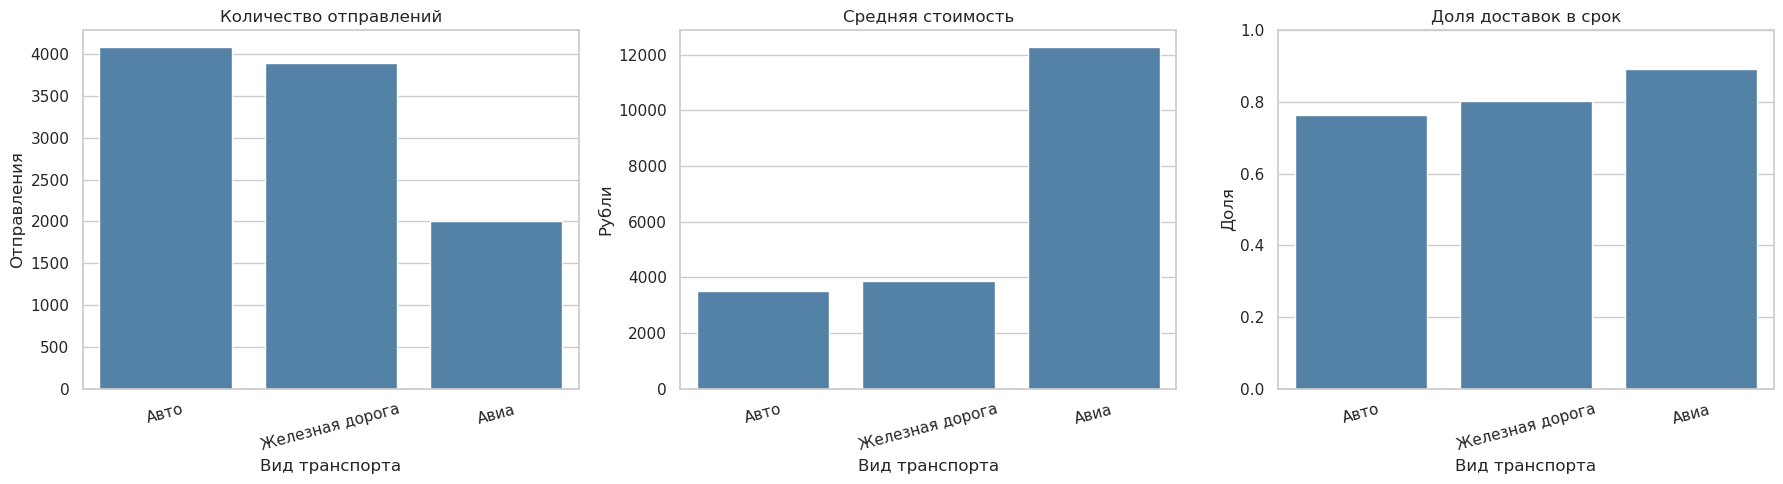

In [15]:
# Группируем отправления по виду транспорта.
transport_summary = analysis_df.groupby('transport_type', as_index=False).agg(
    shipments=('shipment_id', 'nunique'),
    average_cost_rub=('delivery_cost_rub', 'mean'),
    median_cost_rub=('delivery_cost_rub', 'median'),
    average_actual_days=('actual_days', 'mean'),
    on_time_share=('on_time_flag', 'mean')
)
# Сортируем виды транспорта по количеству отправлений.
transport_summary = transport_summary.sort_values('shipments', ascending=False)
# Показываем сводку.
display(transport_summary)
# Создаём фигуру из трёх областей.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Строим количество отправлений по видам транспорта.
sns.barplot(data=transport_summary, x='transport_type', y='shipments', color='steelblue', ax=axes[0])
# Добавляем заголовок первой области.
axes[0].set_title('Количество отправлений')
# Подписываем оси первой области.
axes[0].set(xlabel='Вид транспорта', ylabel='Отправления')
# Строим среднюю стоимость по видам транспорта.
sns.barplot(data=transport_summary, x='transport_type', y='average_cost_rub', color='steelblue', ax=axes[1])
# Добавляем заголовок второй области.
axes[1].set_title('Средняя стоимость')
# Подписываем оси второй области.
axes[1].set(xlabel='Вид транспорта', ylabel='Рубли')
# Строим долю доставок в срок.
sns.barplot(data=transport_summary, x='transport_type', y='on_time_share', color='steelblue', ax=axes[2])
# Добавляем заголовок третьей области.
axes[2].set_title('Доля доставок в срок')
# Подписываем оси третьей области.
axes[2].set(xlabel='Вид транспорта', ylabel='Доля')
# Ограничиваем шкалу доли диапазоном от нуля до единицы.
axes[2].set_ylim(0, 1)
# Поворачиваем подписи категорий на всех трёх графиках.
for axis in axes:
    # Поворачиваем подписи горизонтальной оси.
    axis.tick_params(axis='x', rotation=15)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем графики.
plt.show()

## 20. Города и маршруты

Маршрут — пара «город отправления → город назначения». Рейтинг маршрутов по количеству показывает, где сосредоточен поток. Доля задержек помогает выделить направления, которые требуют проверки. Высокая доля на малом количестве отправлений может быть нестабильной, поэтому объём и качество оцениваются вместе.

,route,origin_city,destination_city,shipments,average_cost_rub,average_actual_days,delay_share
19,Москва → Казань,Москва,Казань,522,"3,562.78",3.26,0.19
22,Москва → Пермь,Москва,Пермь,497,"4,702.57",3.97,0.17
23,Москва → Ростов-на-Дону,Москва,Ростов-на-Дону,491,"4,466.87",3.73,0.24
24,Москва → Самара,Москва,Самара,473,"4,399.28",3.55,0.18
18,Москва → Екатеринбург,Москва,Екатеринбург,472,"5,531.84",3.96,0.19
21,Москва → Новосибирск,Москва,Новосибирск,462,"10,632.51",5.06,0.15
26,Москва → Уфа,Москва,Уфа,452,"4,786.99",3.99,0.19
20,Москва → Нижний Новгород,Москва,Нижний Новгород,449,"2,768.59",2.74,0.24
25,Москва → Санкт-Петербург,Москва,Санкт-Петербург,436,"3,458.98",3.37,0.22
43,Санкт-Петербург → Самара,Санкт-Петербург,Самара,215,"6,138.52",3.83,0.20


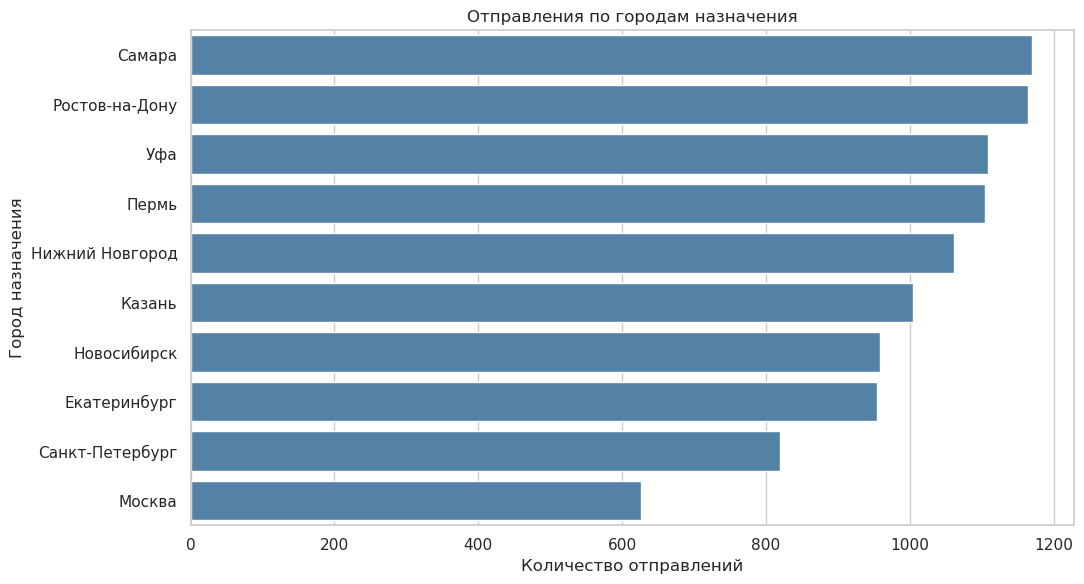

In [16]:
# Группируем данные по маршрутам.
route_summary = analysis_df.groupby(['route', 'origin_city', 'destination_city'], as_index=False).agg(
    shipments=('shipment_id', 'nunique'),
    average_cost_rub=('delivery_cost_rub', 'mean'),
    average_actual_days=('actual_days', 'mean'),
    delay_share=('on_time_flag', lambda series: 1 - series.mean())
)
# Сортируем маршруты по количеству отправлений.
route_summary = route_summary.sort_values('shipments', ascending=False)
# Показываем десять самых частых маршрутов.
display(route_summary.head(10))
# Группируем данные по городам назначения.
destination_summary = analysis_df.groupby('destination_city', as_index=False).agg(
    shipments=('shipment_id', 'nunique'),
    average_cost_rub=('delivery_cost_rub', 'mean'),
    delay_share=('on_time_flag', lambda series: 1 - series.mean())
)
# Сортируем города назначения по количеству отправлений.
destination_summary = destination_summary.sort_values('shipments', ascending=False)
# Строим горизонтальный рейтинг городов назначения.
ax = sns.barplot(data=destination_summary, y='destination_city', x='shipments', color='steelblue')
# Добавляем заголовок.
ax.set_title('Отправления по городам назначения')
# Подписываем горизонтальную ось.
ax.set_xlabel('Количество отправлений')
# Подписываем вертикальную ось.
ax.set_ylabel('Город назначения')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем график.
plt.show()

## 21. Задержки по маршрутам

Средняя доля задержек по маршруту показывает, какая часть отправлений прибыла позже планового срока. Например, значение 0,20 означает, что задержалось примерно 20% отправлений данного направления.

Сравнивать маршруты нужно только при достаточном числе наблюдений. Один задержанный заказ из двух даёт долю 50%, но такой результат нестабилен. Поэтому в график включаются маршруты, где накопилось не менее 50 отправлений. Это делает сравнение понятнее и снижает риск вывода по слишком маленькой группе.

График показывает маршруты с наибольшей долей задержек среди достаточно крупных направлений. Он помогает определить, какие маршруты стоит проверить подробнее: изучить сезонность, вид транспорта, плановые сроки и причины отклонений.


,route,shipments,average_cost_rub,average_actual_days,delay_share
10,Казань → Москва,132,"3,353.46",3.41,0.25
17,Казань → Уфа,157,"2,727.79",2.82,0.25
4,Екатеринбург → Пермь,155,"2,492.35",2.74,0.25
20,Москва → Нижний Новгород,449,"2,768.59",2.74,0.24
15,Казань → Самара,160,"2,543.29",2.81,0.24
23,Москва → Ростов-на-Дону,491,"4,466.87",3.73,0.24
1,Екатеринбург → Москва,173,"5,520.13",4.09,0.24
44,Санкт-Петербург → Уфа,215,"6,057.40",4.86,0.23
42,Санкт-Петербург → Ростов-на-Дону,207,"6,008.95",4.50,0.23
6,Екатеринбург → Самара,158,"3,543.43",3.66,0.23


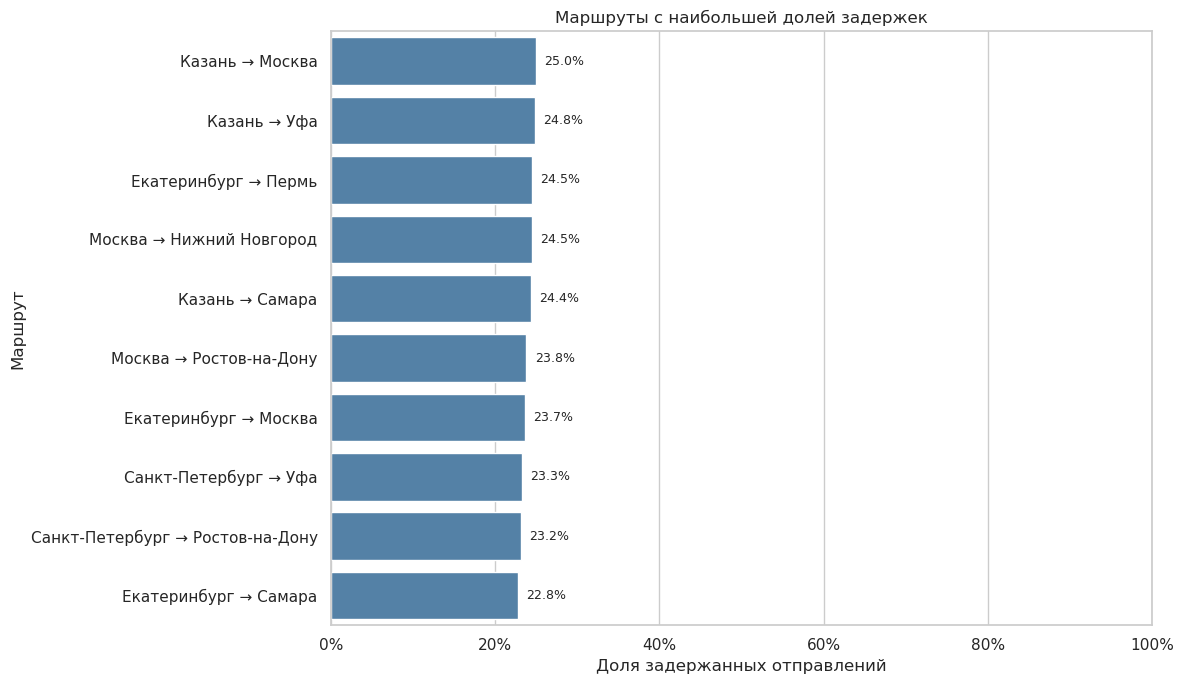

In [17]:
# Оставляем маршруты, где есть не менее 50 отправлений.
reliable_routes = route_summary.loc[route_summary['shipments'] >= 50].copy()
# Сортируем маршруты от наибольшей доли задержек к наименьшей.
reliable_routes = reliable_routes.sort_values('delay_share', ascending=False)
# Выбираем десять маршрутов с наибольшей долей задержек.
top_delayed_routes = reliable_routes.head(10)
# Показываем таблицу с объёмом, средней стоимостью, сроком и долей задержек.
display(top_delayed_routes[['route', 'shipments', 'average_cost_rub', 'average_actual_days', 'delay_share']])
# Создаём отдельную область для горизонтальной диаграммы.
fig, route_delay_axis = plt.subplots(figsize=(12, 7))
# Строим горизонтальную диаграмму доли задержек по выбранным маршрутам.
sns.barplot(data=top_delayed_routes, y='route', x='delay_share', color='steelblue', ax=route_delay_axis)
# Добавляем содержательный заголовок.
route_delay_axis.set_title('Маршруты с наибольшей долей задержек')
# Подписываем горизонтальную ось.
route_delay_axis.set_xlabel('Доля задержанных отправлений')
# Подписываем вертикальную ось.
route_delay_axis.set_ylabel('Маршрут')
# Ограничиваем шкалу доли диапазоном от нуля до единицы.
route_delay_axis.set_xlim(0, 1)
# Форматируем значения горизонтальной оси как проценты.
route_delay_axis.xaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
# Добавляем подписи долей в конце каждого столбца.
for bar in route_delay_axis.patches:
    # Получаем длину столбца, которая соответствует доле задержек.
    bar_value = bar.get_width()
    # Размещаем процентную подпись немного правее конца столбца.
    route_delay_axis.text(bar_value + 0.01, bar.get_y() + bar.get_height() / 2, f'{bar_value:.1%}', va='center', fontsize=9)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем готовый график.
plt.show()


## 22. Корреляционная матрица и тепловая карта

Корреляция показывает направление и силу связи между двумя числовыми признаками. В работе используется коэффициент Спирмена. Он оценивает монотонную связь по рангам и меньше зависит от формы распределения и единичных выбросов, чем корреляция Пирсона.

Значение около +1 означает, что большие значения одного признака обычно соответствуют большим значениям другого. Значение около −1 означает обратную связь. Значение около нуля означает отсутствие выраженной монотонной связи.

Корреляция не доказывает причинность. Например, стоимость и расстояние могут расти вместе, но конкретный тариф также зависит от транспорта и веса.

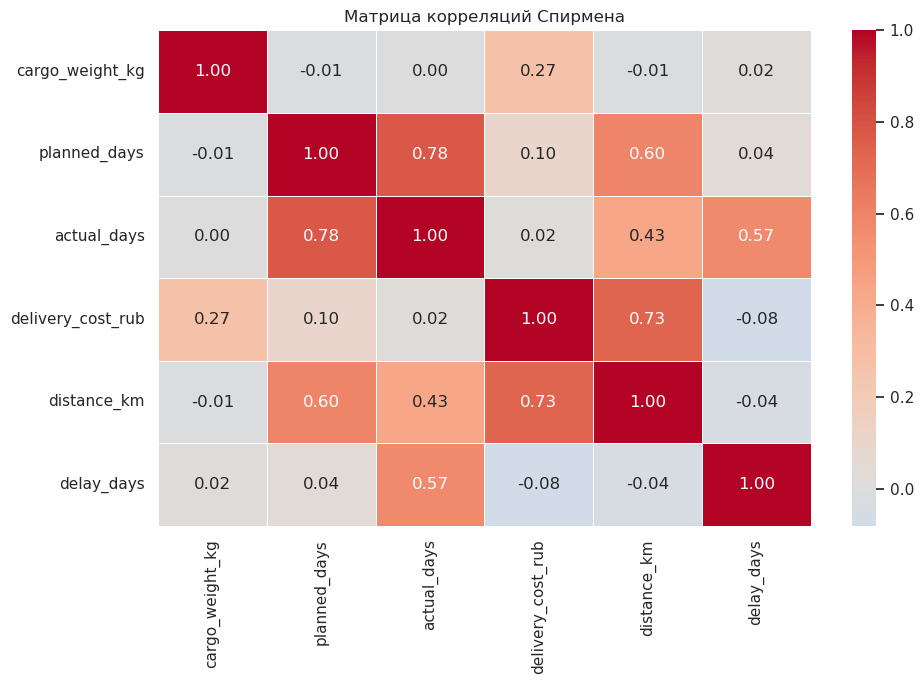

In [18]:
# Выбираем числовые признаки для корреляционного анализа.
correlation_columns = ['cargo_weight_kg', 'planned_days', 'actual_days', 'delivery_cost_rub', 'distance_km', 'delay_days']
# Рассчитываем корреляцию Спирмена.
correlation_matrix = analysis_df[correlation_columns].corr(method='spearman')
# Создаём фигуру для тепловой карты.
plt.figure(figsize=(10, 7))
# Строим тепловую карту с числовыми подписями коэффициентов.
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
# Добавляем заголовок.
plt.title('Матрица корреляций Спирмена')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем тепловую карту.
plt.show()

## 23. Статистическая проверка гипотезы

Проверяется предположение, что авиационные перевозки обычно занимают меньше дней, чем автомобильные.

- Нулевая гипотеза H0: распределение фактического срока авиа не меньше распределения срока авто.
- Альтернативная гипотеза H1: авиационные сроки обычно меньше автомобильных.

Используется тест Манна—Уитни для двух независимых выборок. Он сравнивает ранги значений и не требует нормального распределения. `p-value` показывает, насколько необычен результат при условии справедливости H0. Порог `alpha = 0.05` задаётся до просмотра результата.

Размер эффекта дополняет p-value. Большая выборка способна дать малое p-value даже при небольшом практическом различии.

In [19]:
# Выбираем фактические сроки авиационных отправлений.
air_days = analysis_df.loc[analysis_df['transport_type'] == 'Авиа', 'actual_days']
# Выбираем фактические сроки автомобильных отправлений.
road_days = analysis_df.loc[analysis_df['transport_type'] == 'Авто', 'actual_days']
# Задаём уровень статистической значимости.
alpha = 0.05
# Выполняем односторонний тест Манна—Уитни для гипотезы «авиа меньше авто».
test_result = mannwhitneyu(air_days, road_days, alternative='less', method='asymptotic')
# Извлекаем статистику U.
u_statistic = float(test_result.statistic)
# Извлекаем p-value.
p_value = float(test_result.pvalue)
# Рассчитываем рангово-бисериальный размер эффекта.
rank_biserial = 1 - 2 * u_statistic / (len(air_days) * len(road_days))
# Рассчитываем медиану срока авиационных отправлений.
air_median = float(air_days.median())
# Рассчитываем медиану срока автомобильных отправлений.
road_median = float(road_days.median())
# Печатаем размеры выборок.
print(f'Авиа: n={len(air_days):,}, медиана={air_median:.1f} дня.')
# Печатаем размер автомобильной выборки и медиану.
print(f'Авто: n={len(road_days):,}, медиана={road_median:.1f} дня.')
# Печатаем статистику U.
print(f'U-статистика: {u_statistic:,.1f}')
# Печатаем p-value.
print(f'p-value: {p_value:.6g}')
# Печатаем размер эффекта.
print(f'Рангово-бисериальный размер эффекта: {rank_biserial:.3f}')
# Формулируем статистическое решение без причинного утверждения.
if p_value < alpha:
    # Печатаем решение при статистически значимом результате.
    print('H0 отклоняется: в этом синтетическом наборе авиационные сроки обычно меньше автомобильных.')
else:
    # Печатаем решение при недостатке оснований для отклонения H0.
    print('Недостаточно оснований отклонить H0 на уровне значимости 5%.')

Авиа: n=2,009, медиана=2.0 дня.
Авто: n=4,079, медиана=3.0 дня.
U-статистика: 1,934,563.5
p-value: 4.40296e-263
Рангово-бисериальный размер эффекта: 0.528
H0 отклоняется: в этом синтетическом наборе авиационные сроки обычно меньше автомобильных.


## 24. Итоговый дашборд

Дашборд объединяет шесть графиков:

1. месячное число отправлений;
2. количество отправлений по видам транспорта;
3. средняя стоимость по видам транспорта;
4. доля доставок в срок;
5. основные города назначения;
6. распределение числа дней задержки.

Дашборд не заменяет подробный анализ. Он служит компактной панелью для первичного контроля объёма, стоимости и соблюдения сроков. Географическая схема маршрутов из итоговой версии исключена.


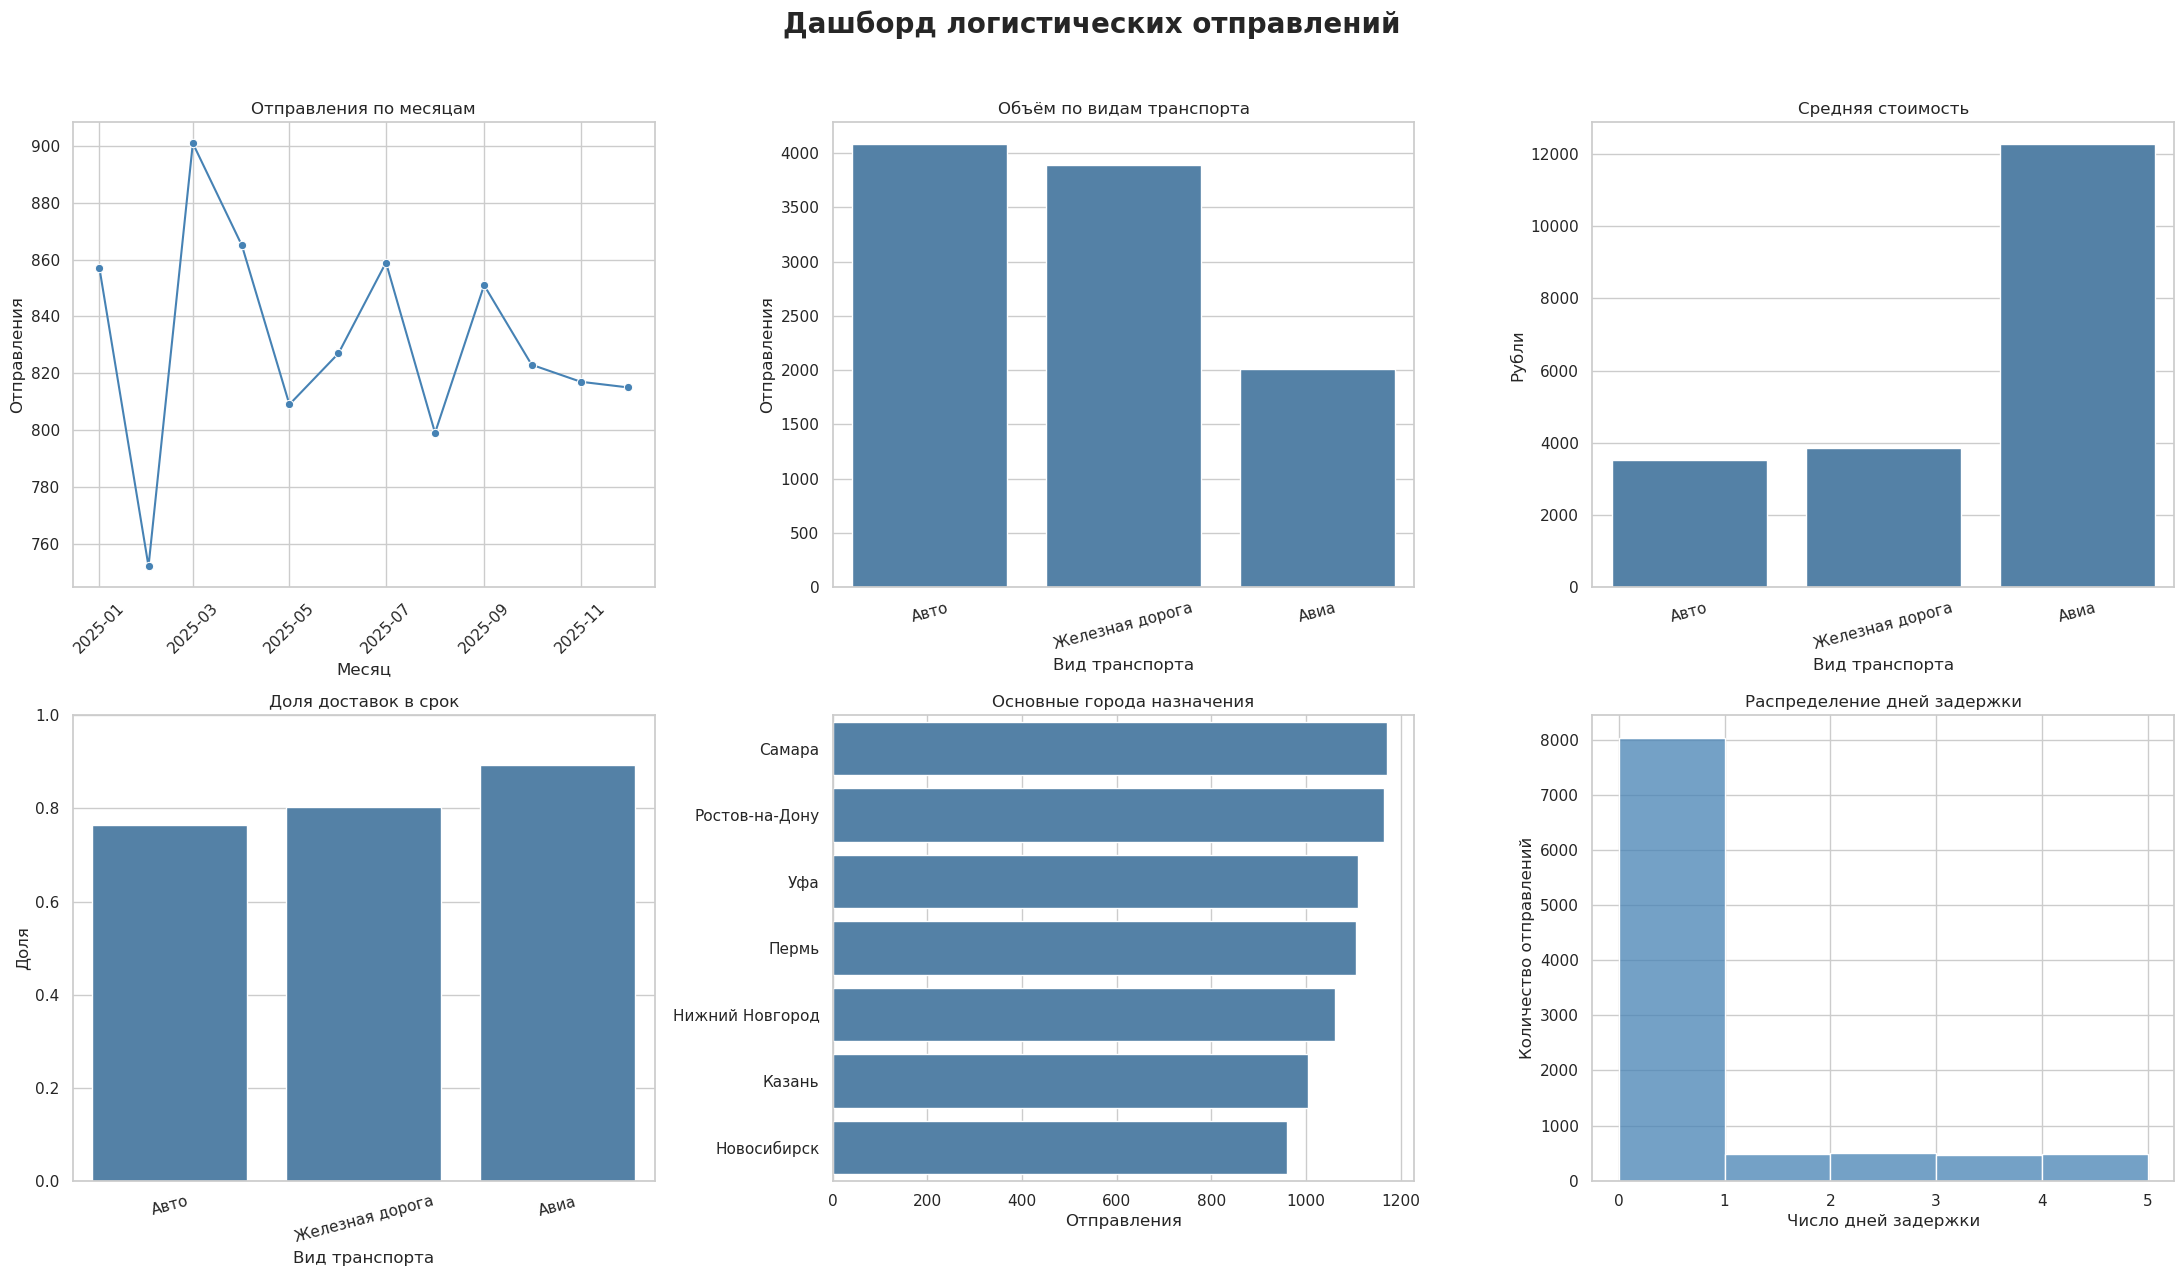

Дашборд сохранён: /home/jovyan/work/28_07_2026/logistics_dashboard.png


In [20]:
# Создаём фигуру дашборда из двух строк и трёх столбцов.
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
# Добавляем общий заголовок дашборда.
fig.suptitle('Дашборд логистических отправлений', fontsize=20, fontweight='bold')

# Строим месячную динамику количества отправлений.
sns.lineplot(data=monthly_summary, x='month', y='shipments', marker='o', color='steelblue', ax=axes[0, 0])
# Настраиваем заголовок первого графика.
axes[0, 0].set_title('Отправления по месяцам')
# Подписываем оси первого графика.
axes[0, 0].set(xlabel='Месяц', ylabel='Отправления')
# Поворачиваем подписи месяцев.
axes[0, 0].tick_params(axis='x', rotation=45)

# Строим количество отправлений по видам транспорта.
sns.barplot(data=transport_summary, x='transport_type', y='shipments', color='steelblue', ax=axes[0, 1])
# Настраиваем заголовок второго графика.
axes[0, 1].set_title('Объём по видам транспорта')
# Подписываем оси второго графика.
axes[0, 1].set(xlabel='Вид транспорта', ylabel='Отправления')
# Поворачиваем подписи категорий.
axes[0, 1].tick_params(axis='x', rotation=15)

# Строим среднюю стоимость по видам транспорта.
sns.barplot(data=transport_summary, x='transport_type', y='average_cost_rub', color='steelblue', ax=axes[0, 2])
# Настраиваем заголовок третьего графика.
axes[0, 2].set_title('Средняя стоимость')
# Подписываем оси третьего графика.
axes[0, 2].set(xlabel='Вид транспорта', ylabel='Рубли')
# Поворачиваем подписи категорий.
axes[0, 2].tick_params(axis='x', rotation=15)

# Строим долю своевременных доставок.
sns.barplot(data=transport_summary, x='transport_type', y='on_time_share', color='steelblue', ax=axes[1, 0])
# Настраиваем заголовок четвёртого графика.
axes[1, 0].set_title('Доля доставок в срок')
# Подписываем оси четвёртого графика.
axes[1, 0].set(xlabel='Вид транспорта', ylabel='Доля')
# Ограничиваем шкалу доли.
axes[1, 0].set_ylim(0, 1)
# Поворачиваем подписи категорий.
axes[1, 0].tick_params(axis='x', rotation=15)

# Выбираем семь крупнейших городов назначения.
top_destinations_dashboard = destination_summary.head(7)
# Строим рейтинг городов назначения.
sns.barplot(data=top_destinations_dashboard, y='destination_city', x='shipments', color='steelblue', ax=axes[1, 1])
# Настраиваем заголовок пятого графика.
axes[1, 1].set_title('Основные города назначения')
# Подписываем оси пятого графика.
axes[1, 1].set(xlabel='Отправления', ylabel='')

# Строим распределение числа дней задержки в шестой области.
sns.histplot(data=analysis_df, x='delay_days', bins=range(0, int(analysis_df['delay_days'].max()) + 2), color='steelblue', ax=axes[1, 2])
# Настраиваем заголовок шестого графика.
axes[1, 2].set_title('Распределение дней задержки')
# Подписываем горизонтальную ось шестого графика.
axes[1, 2].set_xlabel('Число дней задержки')
# Подписываем вертикальную ось шестого графика.
axes[1, 2].set_ylabel('Количество отправлений')

# Корректируем расположение элементов с учётом общего заголовка.
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Сохраняем дашборд в PNG с высоким разрешением.
fig.savefig(DASHBOARD_PATH, dpi=180, bbox_inches='tight')
# Показываем дашборд.
plt.show()
# Печатаем путь к сохранённому дашборду.
print(f'Дашборд сохранён: {DASHBOARD_PATH.resolve()}')

## 25. Выводы, ограничения, рекомендации и финальный QA

### Как читать выводы

Факты подтверждаются расчётами notebook. Интерпретации объясняют наблюдаемые различия. Рекомендации предлагают следующий проверяемый шаг, но не являются автоматически утверждённым управленческим решением.

### Ограничения

- Датасет синтетический и не описывает реальную логистическую компанию.
- Расстояние рассчитано по кратчайшей дуге между координатами городов, а не по реальной транспортной сети. Оно используется только как приближённый числовой признак.
- Стоимость не разделена на топливо, оплату труда, терминальные операции и другие компоненты.
- Наблюдаемая связь не доказывает причинный эффект.
- Статистический тест сравнивает независимые отправления в рамках учебной модели.

### Практические рекомендации

- контролировать одновременно стоимость, срок и долю задержек;
- отдельно проверять маршруты с высоким объёмом и повышенной долей задержек;
- анализировать зимние месяцы как отдельный операционный период;
- для реальной компании добавить расстояние по сети, перевозчика, тип груза, склад и причины задержки;
- перед изменением тарифа или транспорта проверить экономический эффект на фактических данных.

In [21]:
# Находим месяц с максимальным количеством отправлений.
peak_month_row = monthly_summary.loc[monthly_summary['shipments'].idxmax()]
# Находим вид транспорта с максимальной средней стоимостью.
most_expensive_transport_row = transport_summary.loc[transport_summary['average_cost_rub'].idxmax()]
# Находим вид транспорта с минимальной долей своевременных доставок.
lowest_on_time_row = transport_summary.loc[transport_summary['on_time_share'].idxmin()]
# Находим самый частый маршрут.
top_route_row = route_summary.iloc[0]
# Формируем итоговый текст на основании выполненных расчётов.
final_text = f'''
### Итоговые наблюдения по синтетическим данным

- После очистки анализируется **{total_shipments:,} уникальных отправлений**.
- Общая учебная стоимость составляет **{total_cost:,.0f} руб.**, средняя стоимость — **{average_cost:,.0f} руб.**
- Доля доставок в срок составляет **{on_time_share:.1%}**.
- Максимальный месячный объём наблюдается в **{peak_month_row['month']:%Y-%m}**: **{int(peak_month_row['shipments']):,} отправлений**.
- Наибольшая средняя стоимость у вида транспорта **{most_expensive_transport_row['transport_type']}**: **{most_expensive_transport_row['average_cost_rub']:,.0f} руб.**
- Наименьшая доля своевременных доставок у вида транспорта **{lowest_on_time_row['transport_type']}**: **{lowest_on_time_row['on_time_share']:.1%}**.
- Самый частый маршрут — **{top_route_row['route']}**, число отправлений: **{int(top_route_row['shipments']):,}**.

Эти наблюдения описывают синтетический набор и не должны переноситься на реальную компанию без проверки источников, правил расчёта и бизнес-контекста.
'''
# Показываем итоговый текст как Markdown.
display(Markdown(final_text))

# Сохраняем очищенный набор с исходными десятью столбцами.
df[critical_columns].to_csv(CLEAN_DATA_PATH, index=False, encoding='utf-8-sig')
# Проверяем исходный размер датасета.
assert raw_df.shape == (10000, 10), 'Исходный CSV должен содержать 10 000 строк и 10 столбцов.'
# Проверяем, что очищенный набор также содержит только десять столбцов.
assert df[critical_columns].shape[1] == 10, 'Очищенный CSV должен содержать десять столбцов.'
# Проверяем совпадение количества уникальных отправлений и строк очищенной таблицы.
assert df['shipment_id'].nunique() == len(df), 'Количество уникальных отправлений не совпадает с числом строк.'
# Проверяем совпадение общей стоимости и транспортной агрегации.
assert np.isclose(total_cost, analysis_df.groupby('transport_type')['delivery_cost_rub'].sum().sum()), 'Контроль стоимости по видам транспорта не пройден.'
# Проверяем совпадение общей стоимости и маршрутной агрегации.
assert np.isclose(total_cost, analysis_df.groupby('route')['delivery_cost_rub'].sum().sum()), 'Контроль стоимости по маршрутам не пройден.'
# Проверяем конечность статистического результата.
assert np.isfinite(p_value), 'p-value должен быть конечным числом.'
# Проверяем допустимый диапазон размера эффекта.
assert -1 <= rank_biserial <= 1, 'Размер эффекта должен находиться от -1 до 1.'
# Проверяем существование сохранённого очищенного файла.
assert CLEAN_DATA_PATH.exists(), 'Очищенный CSV не сохранён.'
# Проверяем существование сохранённого дашборда.
assert DASHBOARD_PATH.exists(), 'Дашборд не сохранён.'
# Проверяем, что географический PNG не создаётся обновлённой версией notebook.
assert not Path('logistics_geo_preview.png').exists(), 'Географическое превью не должно создаваться.'
# Проверяем, что для анализа задержек выбраны маршруты с достаточным объёмом.
assert (top_delayed_routes['shipments'] >= 50).all(), 'В график задержек попали маршруты с недостаточным объёмом.'
# Печатаем финальный статус проверки.
print('QA PASSED: notebook выполнен, географический график удалён, данные очищены, расчёты согласованы, файлы сохранены.')


### Итоговые наблюдения по синтетическим данным

- После очистки анализируется **9,975 уникальных отправлений**.
- Общая учебная стоимость составляет **54,010,494 руб.**, средняя стоимость — **5,415 руб.**
- Доля доставок в срок составляет **80.6%**.
- Максимальный месячный объём наблюдается в **2025-03**: **901 отправлений**.
- Наибольшая средняя стоимость у вида транспорта **Авиа**: **12,258 руб.**
- Наименьшая доля своевременных доставок у вида транспорта **Авто**: **76.5%**.
- Самый частый маршрут — **Москва → Казань**, число отправлений: **522**.

Эти наблюдения описывают синтетический набор и не должны переноситься на реальную компанию без проверки источников, правил расчёта и бизнес-контекста.


QA PASSED: notebook выполнен, географический график удалён, данные очищены, расчёты согласованы, файлы сохранены.


### Источники по методам

- Универсальный аналитический пайплайн: https://github.com/q10sn1k/DA_MAY_2026/blob/main/item_7/universal_analytics_pipeline_steps.md
- Pandas: https://pandas.pydata.org/docs/
- Matplotlib: https://matplotlib.org/stable/
- Seaborn heatmap: https://seaborn.pydata.org/generated/seaborn.heatmap.html
- SciPy Mann–Whitney U: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html

Документация библиотек может изменяться между версиями. При воспроизведении работы нужно учитывать версии среды из файла `requirements_logistics_analysis.txt`.